In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os
import tensorflow_probability as tfp
tfd = tfp.distributions

tf.config.list_physical_devices('GPU')

[]

# importing data

In [29]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [4]:
df.loc[df['Name'] == "LH_0"].values[0][1:-1]

array([0.309, 0.979, 3.11234, 1.12194, 0.6685, 0.53182], dtype=object)

In [30]:
# out_dir = "../grids/CO/20230327_1-2/"
# out_dir = "../grids/CO/20230403_2/"
out_dir = "../grids/CO/20230403_2_f/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [31]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")
sim_names[:5], sim_names[-5:], sim_names[600:605], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 ['LH_600', 'LH_601', 'LH_602', 'LH_604', 'LH_605'],
 999)

In [19]:
num_samples = len(sim_names)
print(num_samples)
all_curves = np.empty((num_samples, 34, 18, 18, 18))
all_cosmologies = np.empty((num_samples, 6))
for ind, fil in enumerate(sim_names):
    if ind % 100 == 0:
        print(ind)
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
    all_curves[ind] = np.array(list(curves.values()))
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999
0
100
200
300
400
500
600
700
800
900


In [20]:
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves[:])), np.sum(np.isnan(all_cosmologies)))

(999, 34, 18, 18, 18) (999, 6)
0 0


In [21]:
np.savez(f"{out_dir}/all", all_curves=all_curves, all_cosmologies=all_cosmologies)

In [23]:
with np.load(f"{out_dir}/all.npz") as data:
    all_curves = data['all_curves']
    all_cosmologies = data['all_cosmologies']

In [32]:
num_samples = len(sim_names)
print(num_samples)
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves[:])), np.sum(np.isnan(all_cosmologies)))

999
(999, 34, 18, 18, 18) (999, 6)
0 0


In [33]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

train_x, val_x, test_x = map(lambda arr: np.transpose(arr, axes=[0, 2, 3, 4, 1]), [train_x, val_x, test_x])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 18, 18, 18, 34) (100, 18, 18, 18, 34) (50, 18, 18, 18, 34)
(849, 6) (100, 6) (50, 6)


In [ ]:
from scipy.fft import fftn

train_x, val_x, test_x = map(lambda arr: fftn(arr, axes=(1, 2, 3)), [train_x, val_x, test_x])
print(train_x.shape, val_x.shape, test_x.shape)

In [10]:
train_x, val_x, test_x = map(lambda arr: np.nansum(arr, axis=(1)), [train_x, val_x, test_x])
print(train_x.shape, val_x.shape, test_x.shape)

(849, 74, 74, 34) (100, 74, 74, 34) (50, 74, 74, 34)


In [39]:
# input_shape = (74, 74, 74, 34)
input_shape = (18, 18, 18, 34)
output_num = 6

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='leaky_relu', input_shape=input_shape),
  tf.keras.layers.Dense(128, activation='leaky_relu'),
  tf.keras.layers.Conv3D(128, kernel_size=(2, 2, 2), activation='relu'),
  tf.keras.layers.MaxPooling3D(pool_size=(3, 3, 3)),
  tf.keras.layers.Conv3D(128, kernel_size=(3, 3, 3), activation='relu'),
  tf.keras.layers.MaxPooling3D(pool_size=(3, 3, 3)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='leaky_relu'),
  tf.keras.layers.Dense(128, activation='leaky_relu'),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
model.compile(loss='mse', optimizer='adam')
# model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 18, 18, 18, 128)   4480      
                                                                 
 dense_13 (Dense)            (None, 18, 18, 18, 128)   16512     
                                                                 
 conv3d_4 (Conv3D)           (None, 17, 17, 17, 128)   131200    
                                                                 
 max_pooling3d_4 (MaxPooling  (None, 5, 5, 5, 128)     0         
 3D)                                                             
                                                                 
 conv3d_5 (Conv3D)           (None, 3, 3, 3, 128)      442496    
                                                                 
 max_pooling3d_5 (MaxPooling  (None, 1, 1, 1, 128)     0         
 3D)                                                  

In [40]:
# Train the model
history = model.fit(train_x, train_y, epochs=20, validation_data=(val_x, val_y))

Epoch 1/20
27/27 [==============================] - 14s 494ms/step - loss: 0.3443 - val_loss: 0.1433
Epoch 2/20
27/27 [==============================] - 13s 491ms/step - loss: 0.1667 - val_loss: 0.1417
Epoch 3/20
27/27 [==============================] - 13s 496ms/step - loss: 0.1692 - val_loss: 0.1439
Epoch 4/20
27/27 [==============================] - 14s 501ms/step - loss: 0.1671 - val_loss: 0.1710
Epoch 5/20
27/27 [==============================] - 13s 489ms/step - loss: 0.1687 - val_loss: 0.1416
Epoch 6/20
27/27 [==============================] - 13s 493ms/step - loss: 0.1655 - val_loss: 0.1420
Epoch 7/20
27/27 [==============================] - 13s 491ms/step - loss: 0.1672 - val_loss: 0.1441
Epoch 8/20
27/27 [==============================] - 13s 492ms/step - loss: 0.1647 - val_loss: 0.1422
Epoch 9/20
27/27 [==============================] - 13s 493ms/step - loss: 0.1637 - val_loss: 0.1434
Epoch 10/20
27/27 [==============================] - 13s 490ms/step - loss: 0.1632 - val_lo

4/4 [==============================] - 0s 32ms/step


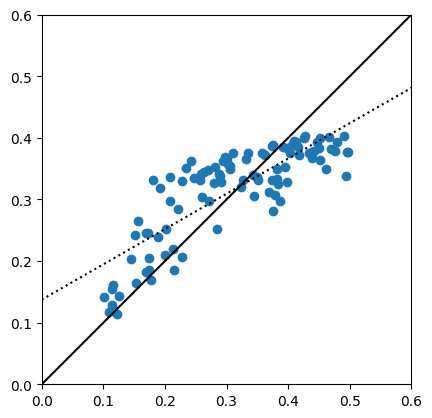

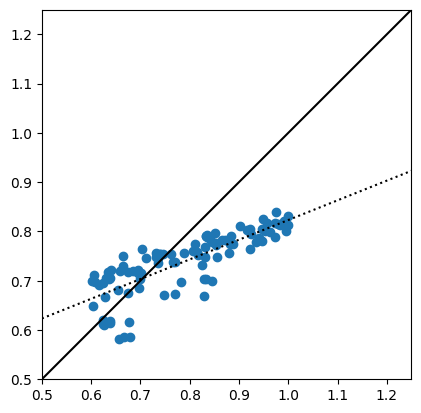

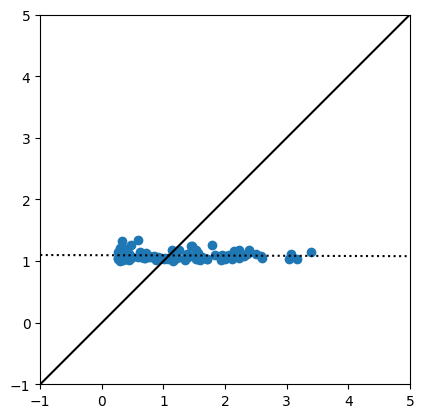

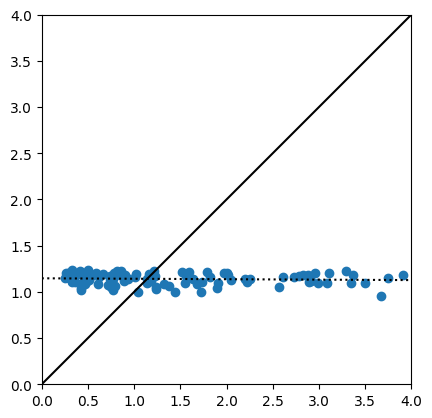

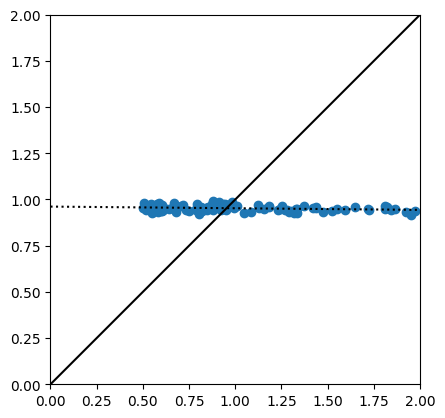

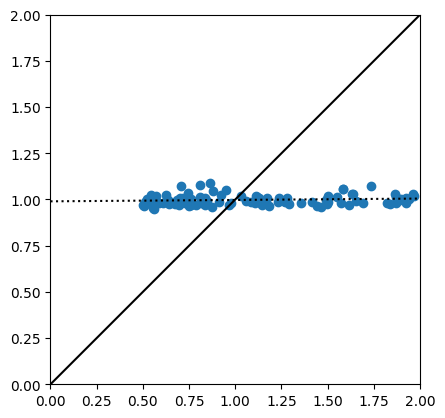

In [41]:
predictions = model.predict(val_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(val_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(val_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()